# mSCA training diagnostics — reaching

In [15]:
import os, importlib
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

import msca, msca.models, msca.architectures, msca.utils, msca.evaluations
importlib.reload(msca.architectures)
importlib.reload(msca.models)
importlib.reload(msca.utils)
importlib.reload(msca.evaluations)
importlib.reload(msca)
from msca import mSCA

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

## Helper

In [16]:
import matplotlib.colors as mcolors

REACH_COLORS = [
    "#e60000", "#ff9900", "#663300", "#33cc00",
    "#00cccc", "#0000ff", "#a366ff", "#ff00ff",
]
_REGION_SHADE = (0.6, 1.55)


def _shade(color, factor):
    r, g, b = mcolors.to_rgb(color)
    if factor <= 1.0:
        return (r * factor, g * factor, b * factor)
    t = min(factor - 1.0, 1.0)
    return (r + (1 - r) * t, g + (1 - g) * t, b + (1 - b) * t)


def plot_latents(
    latents: dict,
    data: dict,
    filter_len: int,
    title: str,
    out_path: Path,
    seed: int = 0,
    row_labels: list | None = None,
) -> None:
    rng = np.random.default_rng(seed)
    regions = [r for r in ("M1", "PMd") if r in latents]
    K = latents[regions[0]][0].shape[1]

    reach_dirs = np.asarray(data["reach_dirs"]).astype(int)
    dirs = sorted(set(reach_dirs.tolist()))
    n_cols = len(dirs)

    cat = [np.concatenate([np.asarray(t) for t in latents[r]], axis=0) for r in regions]
    lo = np.minimum.reduce([c.min(axis=0) for c in cat])
    hi = np.maximum.reduce([c.max(axis=0) for c in cat])

    go  = np.asarray(data["go_idxs"])  if "go_idxs"  in data else None
    tgt = np.asarray(data["tgt_idxs"]) if "tgt_idxs" in data else None

    fig, axs = plt.subplots(K, n_cols, figsize=(12, 8), squeeze=True)

    for col, d in enumerate(dirs):
        trial = int(rng.choice(np.where(reach_dirs == d)[0]))
        color = REACH_COLORS[col % len(REACH_COLORS)]
        for row in range(K):
            ax = axs[row, col]
            for ri, reg in enumerate(regions):
                shade = _shade(color, _REGION_SHADE[ri % len(_REGION_SHADE)])
                ax.plot(np.asarray(latents[reg][trial])[:, row], color=shade, lw=1.2)
            ax.set_ylim(lo[row] - 0.2, hi[row] + 0.2)
            if go is not None:
                ax.axvline(go[trial] - filter_len, color="k", ls="--", lw=0.5)
            if tgt is not None:
                ax.axvline(tgt[trial] - filter_len, color="k", ls="--", lw=0.5)
            if col > 0:
                ax.set_yticks([])
            elif row_labels is not None and row < len(row_labels):
                ax.set_ylabel(row_labels[row], fontsize=6, rotation=0,
                              ha="right", va="center", labelpad=18)
            if row < K - 1:
                ax.set_xticks([])
            ax.tick_params(labelsize=5)
            if row == 0:
                ax.set_title(f"dir {d}", fontsize=7, color=color)

    handles = [
        plt.Line2D([0], [0],
                   color=_shade("0.4", _REGION_SHADE[ri % len(_REGION_SHADE)]),
                   lw=2.0, label=reg)
        for ri, reg in enumerate(regions)
    ]
    fig.legend(handles=handles, loc="upper right", frameon=False, fontsize=8)
    fig.suptitle(title, fontsize=10)

    out_path.parent.mkdir(parents=True, exist_ok=True)
    # fig.savefig(out_path, dpi=1200)
    # plt.close(fig)
    # print(f"[saved] {out_path}")
    fig.show()

## 1. Load data

In [17]:
data = torch.load("./data/x_target_aligned.pt", weights_only=False)

X = {
    "M1":  [x.astype("float32") for x in data["M1"]],
    "PMd": [x.astype("float32") for x in data["PMd"]],
}

print(f"M1:  {len(X['M1'])} trials, {X['M1'][0].shape[1]} neurons, {X['M1'][0].shape[0]} time pts")
print(f"PMd: {len(X['PMd'])} trials, {X['PMd'][0].shape[1]} neurons")


M1:  222 trials, 84 neurons, 309 time pts
PMd: 222 trials, 210 neurons


## 2. Train or load mSCA

In [18]:
RESULTS_DIR  = Path("./results")
MODEL_PATH   = RESULTS_DIR / "msca_nonlinearDecoder_warmup_1000_balance_1000.pt"
LOSSES_PATH  = str(RESULTS_DIR / "losses_nonlinearDecoder_warmup_1000_balance_1000.npz")

MSCA_KWARGS = dict(
    n_components        = 20,
    loss_func           = "Poisson",
    n_epochs            = 5000,
    post_hoc_epoch      = -1,
    linear              = False,
    lam_region          = 0.0,
    decoder_type        = "nonlinear",
    decoder_hidden_size = 40,
    decoder_activation  = "tanh",
    cd_rate             = 0.5,
    cd_mode             = "both",
    filter_len          = 41,
    init                = "unique",
    decoder_init_mode   = "pca",
    sparsity_warmup_epochs = 1000,
    balance_interval = 1000,
)

if MODEL_PATH.exists() and Path(LOSSES_PATH).exists():
    print("Loading saved model and losses...")
    model = mSCA(**MSCA_KWARGS)
    model.load(str(MODEL_PATH), X)
    losses = mSCA.load_losses(LOSSES_PATH)
else:
    print("Training mSCA...")
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    model, losses, lam_dicts, grad_dicts = mSCA(**MSCA_KWARGS).fit(X)
    model.save(str(MODEL_PATH))
    model.save_losses(losses, LOSSES_PATH)
    print(f"Saved model → {MODEL_PATH}")

Loading saved model and losses...
Using region-weights = {'M1': 1.4286866669979845, 'PMd': 0.7691973610519625}
Using lam_sparse = adaptive
Using lam_orthog = 3839.3125
Using lam_region = 0.0


## 3. Loss curves

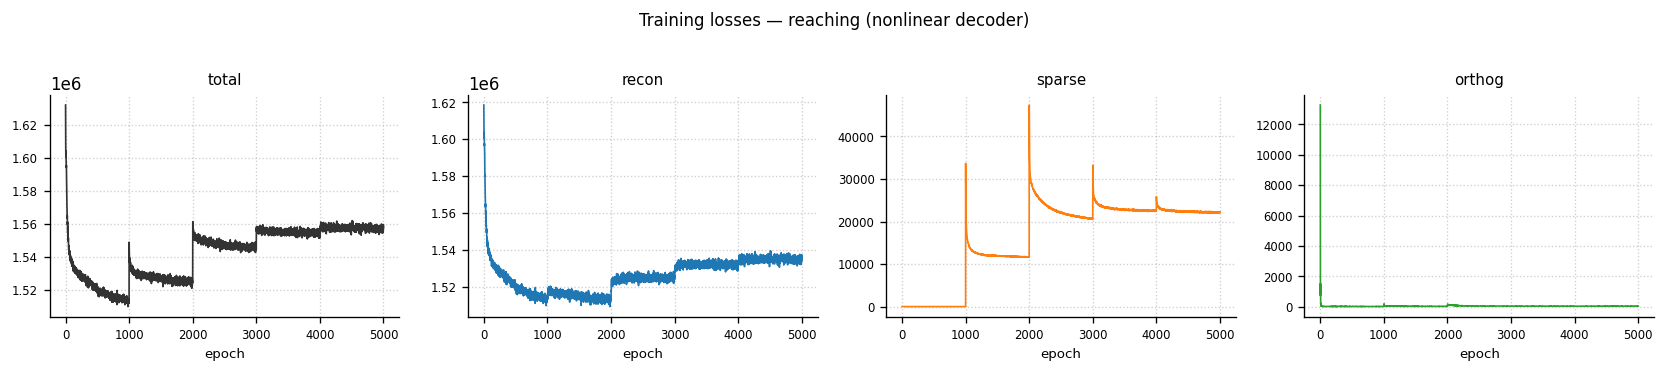

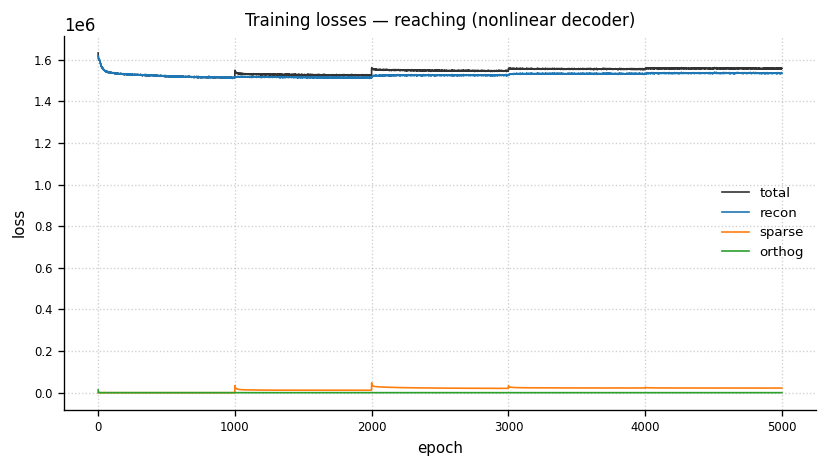

In [19]:
LOSS_KEYS = ["total_loss", "reconstruction", "latent_sparsity", "orthogonality"]
LOSS_LABELS = ["total", "recon", "sparse", "orthog"]
COLORS = ["#333333", "#1f77b4", "#ff7f0e", "#2ca02c"]

fig, axes = plt.subplots(1, len(LOSS_KEYS), figsize=(14, 3))

for ax, key, label, color in zip(axes, LOSS_KEYS, LOSS_LABELS, COLORS):
    if key in losses:
        vals = losses[key]
        ax.plot(vals, color=color, lw=1)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("epoch", fontsize=8)
    ax.grid(ls=":", alpha=0.6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=7)

plt.suptitle("Training losses — reaching (nonlinear decoder)", fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

# summary plot
fig, ax = plt.subplots(figsize=(7, 4))

for key, label, color in zip(LOSS_KEYS, LOSS_LABELS, COLORS):
    if key in losses:
        ax.plot(losses[key], color=color, lw=1, label=label)

ax.set_xlabel("epoch", fontsize=9)
ax.set_ylabel("loss", fontsize=9)
ax.legend(frameon=False, fontsize=8)
ax.grid(ls=":", alpha=0.6)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=7)
ax.set_title("Training losses — reaching (nonlinear decoder)", fontsize=10)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "losses.pdf", bbox_inches="tight")
plt.show()

Loading saved model and losses...
Using region-weights = {'M1': 1.4286866669979845, 'PMd': 0.7691973610519625}
Using lam_sparse = adaptive
Using lam_orthog = 3839.3125
Using lam_region = 0.0


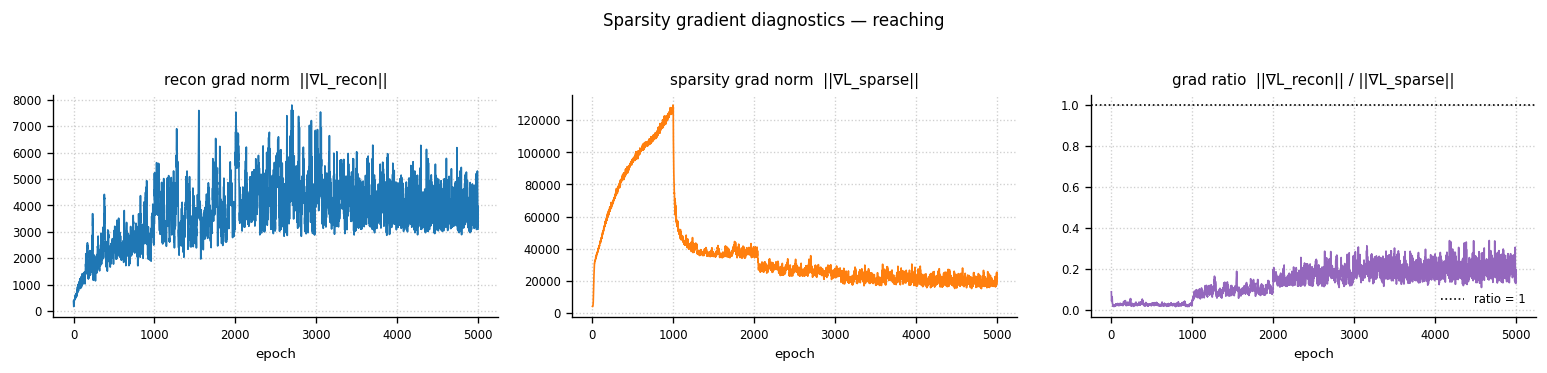

In [26]:
RESULTS_DIR  = Path("./results")
MODEL_PATH   = RESULTS_DIR / "msca_nonlinearDecoder_warmup_1000_balance_1000.pt"
LOSSES_PATH  = str(RESULTS_DIR / "losses_nonlinearDecoder_warmup_1000_balance_1000.npz")

MSCA_KWARGS = dict(
    n_components        = 20,
    loss_func           = "Poisson",
    n_epochs            = 5000,
    post_hoc_epoch      = -1,
    linear              = False,
    lam_region          = 0.0,
    decoder_type        = "nonlinear",
    decoder_hidden_size = 40,
    decoder_activation  = "tanh",
    cd_rate             = 0.5,
    cd_mode             = "both",
    filter_len          = 41,
    init                = "unique",
    decoder_init_mode   = "pca",
)

if MODEL_PATH.exists() and Path(LOSSES_PATH).exists():
    print("Loading saved model and losses...")
    model = mSCA(**MSCA_KWARGS)
    model.load(str(MODEL_PATH), X)
    losses = mSCA.load_losses(LOSSES_PATH)
    checkpoint = torch.load(str(MODEL_PATH), weights_only=False)
    grad_dicts = checkpoint.get("train_gradient_dicts", None)
    lam_dicts  = checkpoint.get("train_lambda_dicts",  None)
else:
    print("Training mSCA...")
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    model, losses, lam_dicts, grad_dicts = mSCA(**MSCA_KWARGS).fit(X)
    model.save(str(MODEL_PATH))
    model.save_losses(losses, LOSSES_PATH)
    print(f"Saved model → {MODEL_PATH}")
assert grad_dicts is not None, "grad_dicts not found — re-train to generate gradient history"

r_grad  = np.asarray(grad_dicts["r_grad"])   # recon gradient norm per epoch
l1_grad = np.asarray(grad_dicts["l1_grad"])  # sparsity gradient norm per epoch
ratio   = r_grad / (l1_grad + 1e-12)         # adaptive λ target: ratio → 1

epochs = np.arange(len(r_grad))

fig, axes = plt.subplots(1, 3, figsize=(13, 3))

axes[0].plot(epochs, r_grad,  color="#1f77b4", lw=1)
axes[0].set_title("recon grad norm  ||∇L_recon||", fontsize=9)

axes[1].plot(epochs, l1_grad, color="#ff7f0e", lw=1)
axes[1].set_title("sparsity grad norm  ||∇L_sparse||", fontsize=9)

axes[2].plot(epochs, ratio,   color="#9467bd", lw=1)
axes[2].axhline(1.0, color="k", ls=":", lw=1, label="ratio = 1")
axes[2].set_title("grad ratio  ||∇L_recon|| / ||∇L_sparse||", fontsize=9)
axes[2].legend(frameon=False, fontsize=7)

for ax in axes:
    ax.set_xlabel("epoch", fontsize=8)
    ax.grid(ls=":", alpha=0.6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=7)

plt.suptitle("Sparsity gradient diagnostics — reaching", fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "grad_norms.pdf", bbox_inches="tight")
plt.show()

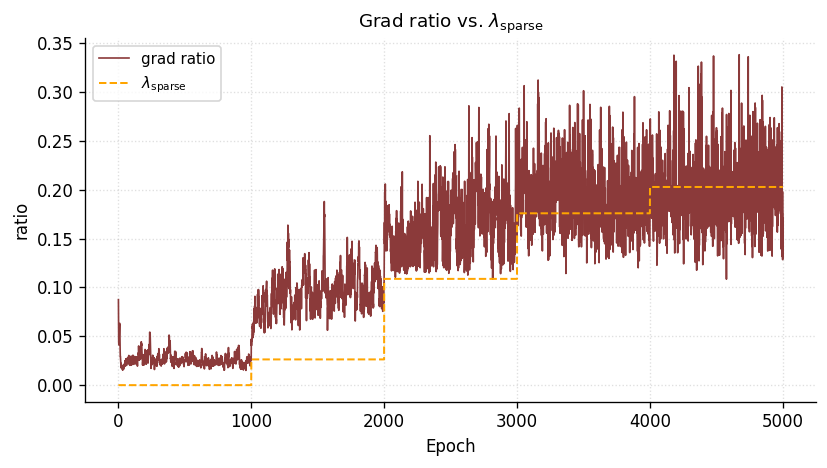

In [27]:
r_grad  = np.asarray(grad_dicts["r_grad"])
l1_grad = np.asarray(grad_dicts["l1_grad"])
ratio   = r_grad / (l1_grad + 1e-12)
lam     = np.asarray(lam_dicts["lam_sparse"])

epochs = np.arange(len(ratio))

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(epochs, ratio, color="#8B3A3A", lw=1,   label="grad ratio")
ax.plot(epochs, lam,   color="#FFA500", lw=1.2, label=r"$\lambda_{\rm sparse}$", linestyle="--")

ax.set_xlabel("Epoch", fontsize=10)
ax.set_ylabel("ratio", fontsize=10)
ax.set_title(r"Grad ratio vs. $\lambda_{\rm sparse}$", fontsize=11)
ax.legend(frameon=True, fontsize=9)
ax.grid(ls=":", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


## 4. Latents

In [28]:
Z = model.transform(X)
print(f"Z['M1'][0].shape  = {Z['M1'][0].shape}")
print(f"Z['PMd'][0].shape = {Z['PMd'][0].shape}")

Z['M1'][0].shape  = (229, 20)
Z['PMd'][0].shape = (229, 20)


/var/folders/lm/hpfh84_s6p71hgkdg87dg0cm0000gn/T/ipykernel_6563/24518311.py:81: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


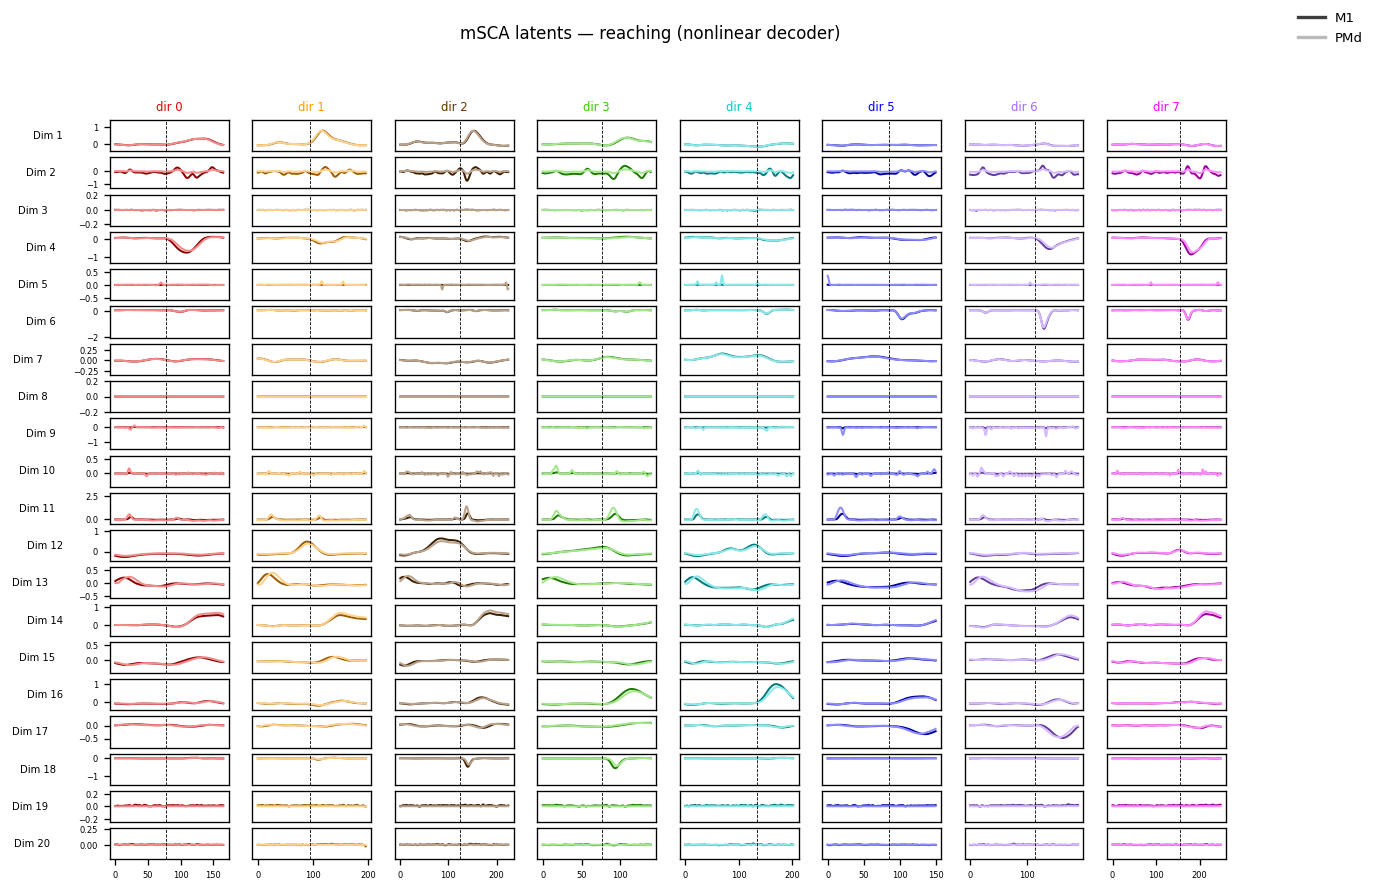

In [29]:
plot_latents(
    latents  = Z,
    data     = data,
    filter_len = model.filter_len,
    title    = "mSCA latents — reaching (nonlinear decoder)",
    out_path = RESULTS_DIR / "latents.pdf",
    seed     = 50,
    row_labels = [f"Dim {k+1}" for k in range(model.n_components)],
)

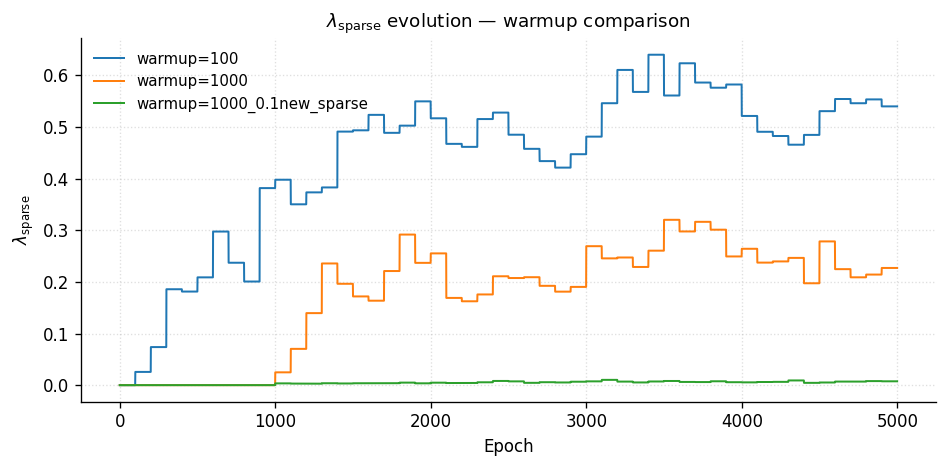

In [30]:
import torch
import numpy as np
import matplotlib.pyplot as plt

RESULTS = "./results"

conditions = {
    "warmup=100":  f"{RESULTS}/msca_nonlinearDecoder_warmup.pt",
    "warmup=1000": f"{RESULTS}/msca_nonlinearDecoder_warmup_1000.pt",
    "warmup=1000_0.1new_sparse": f"{RESULTS}/msca_nonlinearDecoder_warmup_1000_0.1new_sparse.pt",
}
COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c"]

fig, ax = plt.subplots(figsize=(8, 4))

for (label, path), color in zip(conditions.items(), COLORS):
    ckpt = torch.load(path, weights_only=False)
    lam  = np.asarray(ckpt["train_lambda_dicts"]["lam_sparse"])
    ax.plot(np.arange(len(lam)), lam, color=color, lw=1.2, label=label)

ax.set_xlabel("Epoch", fontsize=10)
ax.set_ylabel(r"$\lambda_{\rm sparse}$", fontsize=10)
ax.set_title(r"$\lambda_{\rm sparse}$ evolution — warmup comparison", fontsize=11)
ax.legend(frameon=False, fontsize=9)
ax.grid(ls=":", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


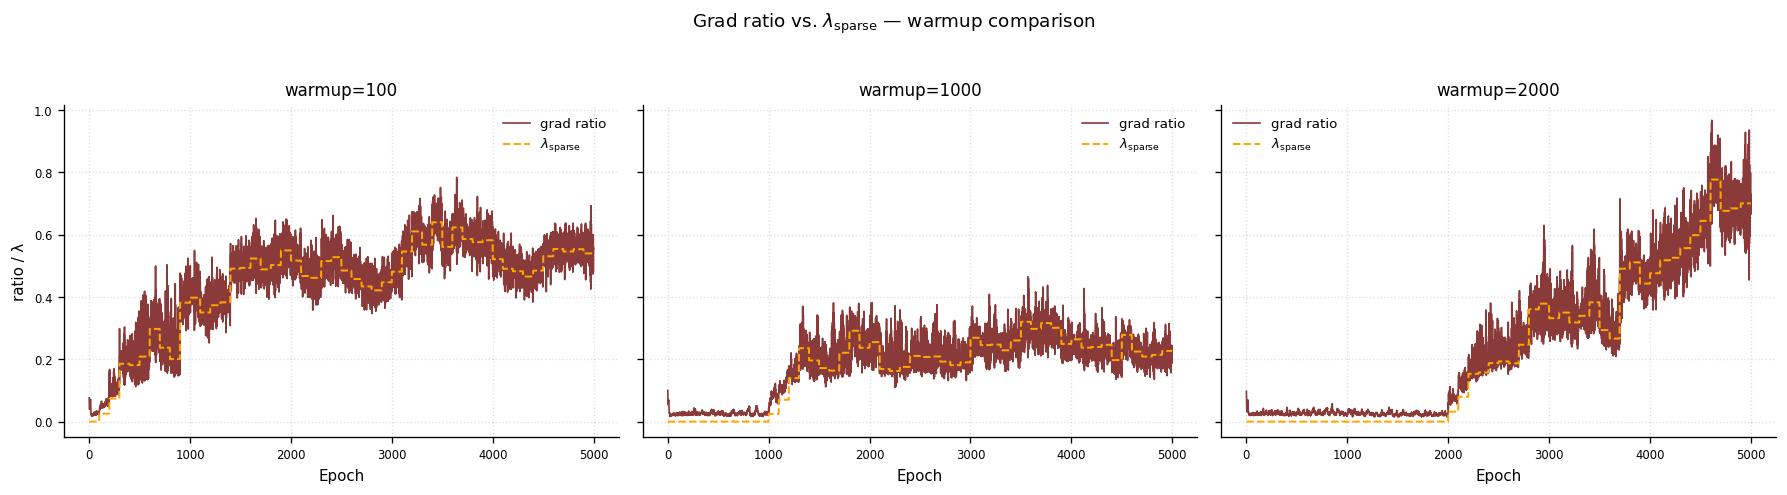

In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt

RESULTS = "./results"

conditions = {
    "warmup=100":  f"{RESULTS}/msca_nonlinearDecoder_warmup.pt",
    "warmup=1000": f"{RESULTS}/msca_nonlinearDecoder_warmup_1000.pt",
    "warmup=2000": f"{RESULTS}/msca_nonlinearDecoder_warmup_2000.pt",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (label, path) in zip(axes, conditions.items()):
    ckpt    = torch.load(path, weights_only=False)
    r_grad  = np.asarray(ckpt["train_gradient_dicts"]["r_grad"])
    l1_grad = np.asarray(ckpt["train_gradient_dicts"]["l1_grad"])
    ratio   = r_grad / (l1_grad + 1e-12)
    lam     = np.asarray(ckpt["train_lambda_dicts"]["lam_sparse"])

    epochs = np.arange(len(ratio))

    ax.plot(epochs, ratio, color="#8B3A3A", lw=1,   label="grad ratio")
    ax.plot(epochs, lam,   color="#FFA500", lw=1.2, label=r"$\lambda_{\rm sparse}$", linestyle="--")

    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Epoch", fontsize=9)
    ax.legend(frameon=False, fontsize=8)
    ax.grid(ls=":", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=7)

axes[0].set_ylabel("ratio / λ", fontsize=9)
plt.suptitle(r"Grad ratio vs. $\lambda_{\rm sparse}$ — warmup comparison", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()
